# Logic Gates with a Perceptron and an MLP

This notebook implements backpropagation **by hand** (raw NumPy, no framework) for the XOR logic gate, matching the derivation in the beamer slides (`sections/perceptron.tex`, `sections/mlp.tex`):

1. A **single-layer perceptron** is trained on XOR -- and fails, because XOR is not linearly separable.
2. An **MLP with one hidden layer** is trained on the same data -- and succeeds, because the hidden layer lets the network bend its decision boundary.

Both use the exact forward/backward-propagation equations derived in the slides.

## 1. Imports

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt


## 2. Single-layer perceptron on XOR (expected to fail)

We build the smallest possible network -- one perceptron, no hidden layer -- and train it with the hand-derived gradient descent update from `sections/perceptron.tex`. XOR is not linearly separable, so this network **cannot** drive the cost to zero, no matter how long we train.

Epoch =      0  Cost = 1.3285
Epoch =   2000  Cost = 1.0000
Epoch =   4000  Cost = 1.0000
Epoch =   6000  Cost = 1.0000
Epoch =   8000  Cost = 1.0000

[target | predicted]
[[0.  0.5]
 [1.  0.5]
 [1.  0.5]
 [0.  0.5]]


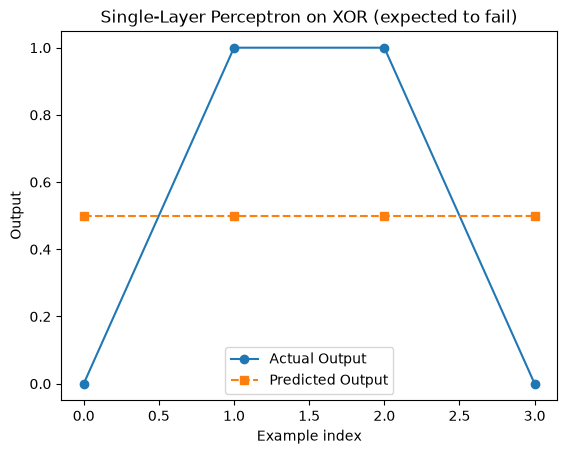

In [2]:
# Define the sigmoid activation function
sigmoid = lambda Z: 1 / (1 + np.exp(-Z))

# Define the derivative of the sigmoid function
dsigmoid = lambda A: A * (1 - A)

# Input data representing possible logic gate inputs
X = np.array([[0,0],[0,1],[1,0],[1,1]])

# Dictionary containing different logic gates and their expected outputs
LogicGate = {
    "AND": [[0], [0], [0], [1]],
    "NAND": [[1], [1], [1], [0]],
    "OR": [[0], [1], [1], [1]],
    "NOR": [[1], [0], [0], [0]],
    "XOR": [[0], [1], [1], [0]],
    "NXOR": [[1], [0], [0], [1]]
}

# Selecting the gate as the target output
# NOTE: XOR is NOT linearly separable, so a single-layer perceptron
# (this cell) is expected to FAIL here -- that failure is the point!
# See the next cell (MLP with a hidden layer) for the fix.
y = np.array(LogicGate["XOR"], dtype=float)

# Setting hyperparameters
alpha = 0.9  # Learning rate
epochs = 10000  # Number of training iterations

# Extract the number of observations (N) and features (K)
N, K = X.shape  # N = 4 (rows), K = 2 (columns)
Ni = K  # Number of neurons in the input layer (2)
No = 1  # Number of neurons in the output layer (1)

# Set random seed for reproducibility
np.random.seed(20240221)

# Initialize weights and bias randomly
w0 = np.random.rand(Ni, No)  # Weight matrix of shape (2,1)
b0 = np.random.rand(1, No)   # Bias matrix of shape (1,1)

# Initialize variables for tracking training progress
A0 = X  # Input layer activations
yhat = []  # Stores predictions at selected epochs
Cost = []  # Stores cost function values at selected epochs

# Training loop (Forward and Backpropagation)
for idx in range(epochs):
    # Forward Propagation
    Z1 = A0 @ w0 + b0  # Compute weighted sum of inputs
    A1 = sigmoid(Z1)   # Apply sigmoid activation function

    # Compute the cost function (Mean Squared Error-like)
    C = (y - A1).T @ (y - A1)

    # Backpropagation - Compute gradients
    dCdA1 = -2 * (y - A1)  # Derivative of cost w.r.t. A1
    dCdZ1 = dCdA1 * dsigmoid(A1)  # Apply sigmoid derivative

    # Compute weight and bias gradients
    dCdw0 = A0.T @ dCdZ1
    dCdb0 = np.ones([1, N]) @ dCdZ1

    # Update weights and biases using Gradient Descent
    w0 = w0 - alpha * dCdw0
    b0 = b0 - alpha * dCdb0

    # Log progress at specific intervals
    if idx % (epochs / 5) == 0:
        yhat.append(A1.squeeze())  # Store predictions
        Cost.append(C.item())      # Store scalar cost value
        print(f"Epoch = {idx:6d}  Cost = {C.item():.4f}")

# Display the final output comparison (target vs. predicted)
print("\n[target | predicted]")
print(np.hstack([y, A1]))

# Plot the actual vs predicted values
plt.plot(y, "o-", label="Actual Output")
plt.plot(A1, "s--", label="Predicted Output")
plt.xlabel("Example index")
plt.ylabel("Output")
plt.title("Single-Layer Perceptron on XOR (expected to fail)")
plt.legend()
plt.show()


## 3. Adding a hidden layer: MLP solves XOR

Exactly the same training loop, but with one hidden layer of 3 neurons inserted between input and output (as in `sections/mlp.tex`). This is enough extra capacity to bend the decision boundary and separate XOR's classes.

Epoch =      0  Cost = 1.4139
Epoch =   1000  Cost = 0.0038
Epoch =   2000  Cost = 0.0015
Epoch =   3000  Cost = 0.0009
Epoch =   4000  Cost = 0.0007

[target | predicted]
[[0.         0.01189738]
 [1.         0.98921417]
 [1.         0.98927384]
 [0.         0.01211358]]


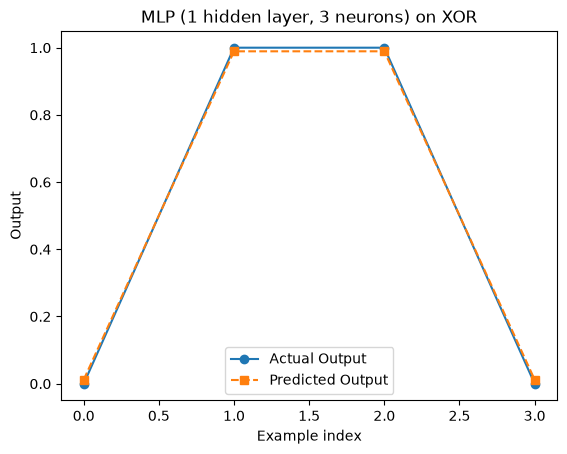

In [ ]:
# Now add ONE hidden layer -- this turns the perceptron into an MLP,
# which CAN solve XOR (unlike the single-layer perceptron above).

# Setting hyperparameters
alpha = 0.9  # Learning rate
epochs = 5000  # Number of training iterations

# Extract the number of observations (N) and features (K)
N, K = X.shape  # N = 4 (rows), K = 2 (columns)
Ni = K   # Number of neurons in the input layer (2)
Nh1 = 3  # Number of neurons in the hidden layer (3)
No = 1   # Number of neurons in the output layer (1)

# Initialize weights and biases randomly
np.random.seed(20240221)  # Set random seed for reproducibility

w0 = np.random.rand(Ni, Nh1)  # Weights between input and hidden layer (2x3)
b0 = np.random.rand(1, Nh1)   # Bias for hidden layer (1x3)
w1 = np.random.rand(Nh1, No)  # Weights between hidden and output layer (3x1)
b1 = np.random.rand(1, No)    # Bias for output layer (1x1)

# Initialize variables for tracking training progress
A0 = X  # Input layer activations
yhat = []  # Stores predictions at selected epochs
Cost = []  # Stores cost function values at selected epochs

# Training loop (Forward and Backpropagation)
for idx in range(epochs):
    # Forward Propagation
    # Layer 1 (Input to Hidden Layer)
    Z1 = A0 @ w0 + b0  # Compute weighted sum for hidden layer
    A1 = sigmoid(Z1)   # Apply activation function for hidden layer

    # Layer 2 (Hidden to Output Layer)
    Z2 = A1 @ w1 + b1  # Compute weighted sum for output layer
    A2 = sigmoid(Z2)   # Apply activation function for output layer

    # Compute the cost function (Mean Squared Error-like)
    C = (y - A2).T @ (y - A2)

    # Backpropagation
    # Layer 2 (Output Layer)
    dCdA2 = -2 * (y - A2)  # Derivative of cost w.r.t A2
    dCdZ2 = dCdA2 * dsigmoid(A2)  # Apply sigmoid derivative

    # Layer 1 (Hidden Layer)
    dCdA1 = dCdZ2 @ w1.T  # Backpropagate error to hidden layer
    dCdZ1 = dCdA1 * dsigmoid(A1)  # Apply sigmoid derivative

    # Compute gradients for weights and biases
    dCdw1 = A1.T @ dCdZ2  # Gradient for w1
    dCdw0 = A0.T @ dCdZ1  # Gradient for w0
    dCdb1 = np.ones([1, N]) @ dCdZ2  # Gradient for b1
    dCdb0 = np.ones([1, N]) @ dCdZ1  # Gradient for b0

    # Update weights and biases using Gradient Descent
    w1 = w1 - alpha * dCdw1
    b1 = b1 - alpha * dCdb1
    w0 = w0 - alpha * dCdw0
    b0 = b0 - alpha * dCdb0

    # Log progress at specific intervals
    if idx % (epochs / 5) == 0:
        yhat.append(A2.squeeze())  # Store predictions
        Cost.append(C.item())      # Store scalar cost value
        print(f"Epoch = {idx:6d}  Cost = {C.item():.4f}")

# Display the final output comparison (target vs. predicted)
print("\n[target | predicted]")
print(np.hstack([y, A2]))

# Plot the actual vs predicted values
plt.plot(y, "o-", label="Actual Output")
plt.plot(A2, "s--", label="Predicted Output")
plt.xlabel("Example index")
plt.ylabel("Output")
plt.title("MLP (1 hidden layer, 3 neurons) on XOR")
plt.legend()
plt.show()
